In [169]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display, HTML
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch

In [2]:
# customizing 'markdown' font style
display(HTML("""
<style>
.jp-RenderedMarkdown{
    color: red !important;
    font-size: 28px !important;
    font-weight: 700 !important;
}
</style>
"""))

In [3]:
# enable all row display
# pd.set_option('display.max_rows', None)

In [4]:
# enable all column display
pd.set_option('display.max_columns', None)

In [5]:
specifications = pd.read_csv('specifications.csv')

In [6]:
# printing the length of the dataframe
len(specifications)

500

In [7]:
# printing first 2 rows of the dataframe
specifications.head(2)

,Unnamed: 0,company,model,variant,price_start,price_avg,price_max,sales,CNG Highway Mileage,CNG Mileage ARAI,Child Safety Locks,Connectivity,Apple CarPlay,Diesel Highway Mileage,Diesel Mileage ARAI,Petrol Highway Mileage,Petrol Mileage ARAI,Drive Type,Fuel Type,Gearbox,Length,No. of Cylinders,Transmission Type,Displacement
0,0,HYUNDAI,CRETA,Creta E,12.07,20.1021,25.44,626200.0,NaN,NaN,YES,NaN,NO,NaN,NaN,NaN,17.4 kmpl,FWD,Petrol,6-Speed,4330 mm,4,Manual,1497 cc
1,1,HYUNDAI,CRETA,Creta E Diesel,12.07,20.1021,25.44,626200.0,NaN,NaN,YES,NaN,NO,NaN,21.8 kmpl,NaN,NaN,FWD,Diesel,6-Speed,4330 mm,4,Manual,1493 cc


Printing Data Types and Number of Null Values

In [8]:
specifications.dtypes

Unnamed: 0                  int64
company                    object
model                      object
variant                    object
price_start               float64
price_avg                 float64
price_max                 float64
sales                     float64
CNG Highway Mileage        object
CNG Mileage ARAI           object
Child Safety Locks         object
Connectivity               object
Apple CarPlay              object
Diesel Highway Mileage     object
Diesel Mileage ARAI        object
Petrol Highway Mileage     object
Petrol Mileage ARAI        object
Drive Type                 object
Fuel Type                  object
Gearbox                    object
Length                     object
No. of Cylinders            int64
Transmission Type          object
Displacement               object
dtype: object

In [9]:
specifications.isna().sum()

Unnamed: 0                  0
company                     0
model                       0
variant                     0
price_start                57
price_avg                  57
price_max                  57
sales                       0
CNG Highway Mileage       495
CNG Mileage ARAI          468
Child Safety Locks         52
Connectivity              184
Apple CarPlay              15
Diesel Highway Mileage    484
Diesel Mileage ARAI       399
Petrol Highway Mileage    472
Petrol Mileage ARAI       228
Drive Type                  9
Fuel Type                   0
Gearbox                     1
Length                      0
No. of Cylinders            0
Transmission Type           0
Displacement                0
dtype: int64

Processing 'Drive Type'

In [10]:
specifications['Drive Type'].value_counts()

Drive Type
FWD    431
2WD     40
RWD     11
AWD      5
4WD      4
Name: count, dtype: int64

In [11]:
# dropping 'Drive Type' column
specifications = specifications.drop('Drive Type', axis = 1)

Handling Missing Values in 'Gearbox' Column

In [12]:
specifications.loc[(specifications['Gearbox'].isna())][['company', 'model', 'Gearbox']]

,company,model,Gearbox
28,HYUNDAI,CRETA,NaN


In [13]:
specifications.loc[(specifications['variant'] == 'Creta S (O) Knight'), 'Gearbox'] = 'ivT'

In [14]:
specifications['Gearbox'].isna().sum()

np.int64(0)

Processing 'Gearbox' ('6-speed' to '6')

In [15]:
# checking the frequency of each unique values for 'Gearbox'
specifications['Gearbox'].value_counts()

Gearbox
6-Speed              208
5-Speed              129
6-Speed AT            29
6 Speed               27
6-Speed iVT           17
5 Speed AMT           15
6-Speed AMT           14
7-Speed DCT           13
7-Speed DCA            8
7-Speed                7
5 Speed                5
6-Speed iMT            5
6 - Speed              4
4 Speed                4
E-CVT                  4
5-Speed AMT            3
6-speed AutoSHIFT      2
6 -Speed AT            2
7 - Speed DCT          1
6 - Speed AT           1
ivT                    1
5-speed                1
Name: count, dtype: int64

In [16]:
# only keeping the 1st character the 'Gearbox Column'
# example 1: '6-Speed' -> '6'
# example 2: '7-Speed DCT' -> '7'
specifications['Number Of Gears'] = specifications['Gearbox'].str[0]

In [17]:
specifications['Number Of Gears'].value_counts()

Number Of Gears
6    309
5    153
7     29
E      4
4      4
i      1
Name: count, dtype: int64

In [18]:
# replacing values other that '4', '5', '6' and '7' as '0'
# means the 'E' and 'i' -> '0'
# these are either Electric Cars or CVT (Continuously Variable Transmission).
specifications.loc[(specifications['Number Of Gears'].isin(['6', '5', '7', '4']) == False), 'Number Of Gears'] = '0'

In [19]:
specifications['Number Of Gears'].value_counts()

Number Of Gears
6    309
5    153
7     29
0      5
4      4
Name: count, dtype: int64

In [20]:
# dropping column 'Gearbox'
specifications = specifications.drop(['Gearbox'], axis = 1)

In [21]:
# changing data type for 'Number Of Gears'
# specifications['Number Of Gears'] = specifications['Number Of Gears'].astype('int')

In [22]:
# checking data type for 'Number Of Gears'
# specifications['Number Of Gears'].dtypes

Processing 'Cylinders'

In [23]:
# renaming 'No. of Cylinders' -> Cylinders
specifications.rename(columns = {'No. of Cylinders' : 'cylinders'}, inplace = True)

In [24]:
# checking the unique values in column 'cylinders'
specifications['cylinders'].value_counts()

cylinders
4    348
3    152
Name: count, dtype: int64

In [25]:
# checking data type of the column 'cylinders'
specifications['cylinders'].dtype

dtype('int64')

In [26]:
specifications['cylinders'] = specifications['cylinders'].astype(str)

In [27]:
# checking again data type of the column 'cylinders'
specifications['cylinders'].dtype

dtype('O')

Processing 'Displacement' Column

In [28]:
# checking the frequency of each unique values for 'Displacement'
specifications['Displacement'].value_counts()

Displacement
1197 cc    106
1497 cc     92
1462 cc     73
1199 cc     66
1493 cc     64
998 cc      30
1999 cc     16
1482 cc     14
2198 cc     12
1498 cc     10
1490 cc      9
2184 cc      5
1997 cc      3
Name: count, dtype: int64

In [29]:
# only keeping the first 4 characters
specifications['Displacement'] = specifications['Displacement'].apply(lambda cell: cell[:4])

In [30]:
specifications['Displacement'].head(3)

0    1497
1    1493
2    1497
Name: Displacement, dtype: object

In [31]:
# converting data type to float
specifications['Displacement'] = specifications['Displacement'].astype('float')

In [32]:
# categorize engine displacement, new column 'Displacement Category'
def displacement_category(displacement):
    if 950 <= displacement <= 1050:
        return 1000
    elif 1150 <= displacement <= 1250:
        return 1200
    elif 1450 <= displacement <= 1550:
        return 1500
    elif 1950 <= displacement <= 2050:
        return 2000
    elif 2150 <= displacement <= 2250:
        return 2200

specifications['Displacement'] = specifications['Displacement'].apply(displacement_category)

In [33]:
# checking the frequency of each unique values for 'Displacement' after modifications
specifications['Displacement'].value_counts()

Displacement
1500    262
1200    172
1000     30
2000     19
2200     17
Name: count, dtype: int64

In [34]:
specifications['Displacement'].isna().sum()

np.int64(0)

In [35]:
# specifications = specifications.drop(['Displacement'], axis = 1)

Processing Mileage Columns

In [36]:
specifications.loc[(specifications['Petrol Highway Mileage'].isna()), 'Petrol Highway Mileage'] = specifications['Diesel Highway Mileage']

In [37]:
specifications['Petrol Highway Mileage'].isna().sum()

np.int64(456)

In [38]:
specifications.loc[(specifications['Petrol Highway Mileage'].isna()), 'Petrol Highway Mileage'] = specifications['Diesel Highway Mileage']

In [39]:
specifications.loc[(specifications['Petrol Mileage ARAI'].isna()), 'Petrol Mileage ARAI'] = specifications['Diesel Mileage ARAI']

In [40]:
specifications['Petrol Mileage ARAI'].isna().sum()

np.int64(127)

In [41]:
specifications.loc[(specifications['Petrol Mileage ARAI'].isna()), 'Petrol Mileage ARAI'] = specifications['Petrol Highway Mileage']

In [42]:
specifications['Petrol Mileage ARAI'].isna().sum()

np.int64(112)

In [43]:
specifications.loc[(specifications['Petrol Mileage ARAI'].isna()), 'Petrol Mileage ARAI'] = specifications['CNG Mileage ARAI']

In [44]:
specifications.loc[(specifications['Petrol Mileage ARAI'].isna()), 'Petrol Mileage ARAI'] = specifications['CNG Highway Mileage']

In [45]:
specifications['Petrol Mileage ARAI'].isna().sum()

np.int64(75)

In [46]:
# making a new column mileage
specifications['Mileage'] = specifications['Petrol Mileage ARAI']

In [47]:
# checking the number of null values
specifications['Mileage'].isna().sum()

np.int64(75)

In [48]:
# filling the null values with '0'
specifications['Mileage'] = specifications['Mileage'].fillna('0')

In [49]:
# checking again the number of null values
specifications['Mileage'].isna().sum()

np.int64(0)

In [50]:
# checking the data type for mileage column
specifications['Mileage'].dtype

dtype('O')

In [51]:
# taking the first 2 characters only
specifications['Mileage'] = specifications['Mileage'].str[:2]

In [52]:
# converting data type 'Mileage' column to float
specifications['Mileage'] = specifications['Mileage'].astype(float)

In [53]:
# checking again the data type of 'Mileage' column
specifications['Mileage'].dtype

dtype('float64')

In [54]:
# printing the models only with null values in 'Mileage' columns
specifications.loc[specifications['Mileage'].isna()]['model'].value_counts()

Series([], Name: count, dtype: int64)

In [55]:
# dropping the initial 6 mileage related columns
specifications = specifications.drop(['Petrol Mileage ARAI', 'Petrol Highway Mileage', 'Diesel Highway Mileage', 'Diesel Mileage ARAI','CNG Highway Mileage', 'CNG Mileage ARAI'], axis = 1)

Processing 'Length' Columns

In [56]:
# printing the length of each column
# grouping by 'model' and printing the first row
specifications.groupby('model').first()[['Length']]

,Length
model,
BOLERO,3995 mm
CARENS,4540 mm
CRETA,4330 mm
ERTIGA,4395 mm
EXTER,3815 mm
FRONX,3995 mm
GRAND VITARA,4345 mm
HYRYDER,4365 mm
NEXON,3995 mm


In [57]:
specifications['Length'] = specifications['Length'].str[:4]

In [58]:
specifications['Length'].head()

0    4330
1    4330
2    4330
3    4330
4    4330
Name: Length, dtype: object

In [59]:
specifications['Length'] = specifications['Length'].astype('int')

In [60]:
def length_category(length):
    if length <= 4000:
        return 'Small'
    elif 4000 < length <= 4400:
        return 'Medium'
    elif length > 4400:
        return 'Large'

specifications['Length Category'] = specifications['Length'].apply(length_category)

In [61]:
specifications['Length Category'].value_counts()

Length Category
Small     297
Medium    119
Large      84
Name: count, dtype: int64

In [62]:
specifications['Length Category'].isna().sum()

np.int64(0)

In [63]:
specifications = specifications.drop(['Length'], axis = 1)

Exploring 'Transmission Type' Column and Creating 'Automatic Transmission'

In [64]:
specifications['Transmission Type'].value_counts()

Transmission Type
Manual       303
Automatic    197
Name: count, dtype: int64

In [65]:
# creating new column 'Automatic Transmission'
# filling all rows in transmission type 
specifications['Automatic Transmission'] = (
        (specifications['Transmission Type'] == 'Automatic')
        .groupby(specifications['model'])
        .transform('mean') * 100)

In [66]:
# rounding off percentage to 1 decimal place
specifications['Automatic Transmission'] = specifications['Automatic Transmission'].round(1)

In [67]:
specifications['Automatic Transmission'].value_counts()

Automatic Transmission
48.6    70
27.1    70
36.7    60
62.5    40
37.5    40
35.9    39
57.1    28
35.7    28
38.5    26
34.6    26
23.8    21
0.0     18
61.1    18
44.4     9
42.9     7
Name: count, dtype: int64

Processing 'Fuel Type'

In [68]:
# making 2 new columns
specifications[['Petrol', 'Diesel']] = np.nan

In [69]:
# if column 'Fuel Type' = 'Petrol' then column 'Petrol' = 'YES'
# elif column 'Fuel Type' = 'Diesel' then column 'Diesel' = 'YES'
specifications.loc[(specifications['Fuel Type'] == 'Petrol'), 'Petrol'] = 'YES'
specifications.loc[(specifications['Fuel Type'] == 'Diesel'), 'Diesel'] = 'YES'

/var/folders/_7/8mmqgn7s4bjc8l8cr6llqzq80000gn/T/ipykernel_2202/1551944638.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'YES' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  specifications.loc[(specifications['Fuel Type'] == 'Petrol'), 'Petrol'] = 'YES'
/var/folders/_7/8mmqgn7s4bjc8l8cr6llqzq80000gn/T/ipykernel_2202/1551944638.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'YES' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  specifications.loc[(specifications['Fuel Type'] == 'Diesel'), 'Diesel'] = 'YES'


In [70]:
# if column 'Fuel Type' = 'Petrol' then column 'Petrol' = 'YES' AND column 'Diesel' = 'NO'
# elif column 'Fuel Type' = 'Diesel' then column 'Diesel' = 'YES' AND column 'Petrol' = 'NO'
specifications['Petrol'] = (specifications['Fuel Type'] == 'Petrol').map({True: 'YES', False: 'NO'})
specifications['Diesel'] = (specifications['Fuel Type'] == 'Diesel').map({True: 'YES', False: 'NO'})

In [71]:
# printing sample
specifications.head(2)[['company', 'model', 'Fuel Type', 'Petrol', 'Diesel']]

,company,model,Fuel Type,Petrol,Diesel
0,HYUNDAI,CRETA,Petrol,YES,NO
1,HYUNDAI,CRETA,Diesel,NO,YES


In [72]:
# converting columns 'Petrol' and 'Diesel' to percentage
specifications['Petrol'] = (
        (specifications['Petrol'] == 'YES')
        .groupby(specifications['model'])
        .transform('mean') * 100)
specifications['Diesel'] = (
        (specifications['Diesel'] == 'YES')
        .groupby(specifications['model'])
        .transform('mean') * 100)

In [73]:
# printing sample
specifications.head(2)[['company', 'model', 'Fuel Type', 'Petrol', 'Diesel']]

,company,model,Fuel Type,Petrol,Diesel
0,HYUNDAI,CRETA,Petrol,57.142857,42.857143
1,HYUNDAI,CRETA,Diesel,57.142857,42.857143


In [74]:
# removing the 'Fuel Type'
specifications = specifications.drop('Fuel Type', axis = 1)

Processing Price Columns

In [75]:
specifications['price_avg'] = specifications['price_avg'].round(1)
specifications['price_start'] = specifications['price_start'].round(1)
specifications['price_max'] = specifications['price_max'].round(1)

Dropping Irrelevant Columns

In [76]:
# dropping the columns mentioned above
specifications = specifications.drop(['Apple CarPlay', 'Connectivity', 'Child Safety Locks', 'variant'], axis = 1)

Final Dataframe

In [77]:
specifications_final = specifications.groupby('model').first()
specifications_final.to_csv('specifications_final.csv')

In [78]:
specifications_final.isna().sum()

Unnamed: 0                0
company                   0
price_start               0
price_avg                 0
price_max                 0
sales                     0
cylinders                 0
Transmission Type         0
Displacement              0
Number Of Gears           0
Mileage                   0
Length Category           0
Automatic Transmission    0
Petrol                    0
Diesel                    0
dtype: int64

In [79]:
specifications_final

,Unnamed: 0,company,price_start,price_avg,price_max,sales,cylinders,Transmission Type,Displacement,Number Of Gears,Mileage,Length Category,Automatic Transmission,Petrol,Diesel
model,,,,,,,,,,,,,,,
BOLERO,199,MAHINDRA,9.0,10.5,11.9,371400.0,3,Manual,1500,5,16.0,Small,0.0,0.000000,100.000000
CARENS,135,KIA,12.1,14.0,15.8,210775.0,4,Manual,1500,6,15.0,Large,0.0,33.333333,33.333333
CRETA,0,HYUNDAI,12.1,20.1,25.4,626200.0,4,Manual,1500,6,17.0,Medium,48.6,57.142857,42.857143
ERTIGA,214,MARUTI,9.8,11.4,13.3,585400.0,4,Manual,1500,5,20.0,Medium,0.0,66.666667,0.000000
EXTER,70,HYUNDAI,6.4,9.5,11.5,148600.0,4,Manual,1200,5,19.0,Small,35.9,74.358974,0.000000
FRONX,217,MARUTI,7.7,10.7,14.7,301300.0,3,Manual,1000,5,21.0,Small,37.5,87.500000,0.000000
GRAND VITARA,233,MARUTI,11.9,18.3,22.9,296400.0,4,Manual,1500,5,21.0,Medium,57.1,92.857143,0.000000
HYRYDER,369,TOYOTA,12.3,19.3,25.1,132200.0,4,Manual,1500,5,21.0,Medium,61.1,88.888889,0.000000
NEXON,283,TATA,8.2,13.4,17.6,631100.0,3,Manual,1200,6,17.0,Small,36.7,45.000000,33.333333


What to do ?

Comparing Length and Sales

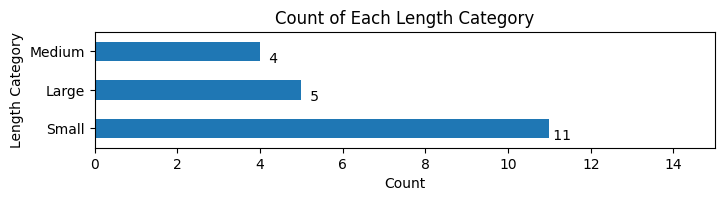

In [101]:
# comparing sales for each 'Length Category'
counts = specifications_final['Length Category'].value_counts()
plt.figure(figsize=(8, 1.5))  # (width, height)
ax = counts.plot(kind='barh')
# Add values on top of bars
for i, v in enumerate(counts):
    ax.text(v, i, '      ' + str(v), ha='center', va='top') 
plt.xlim([0, 15])
plt.xlabel('Count')
plt.ylabel('Length Category')
plt.title('Count of Each Length Category')
plt.show()

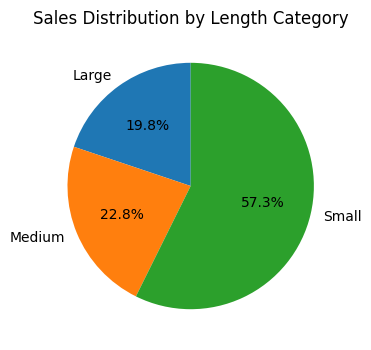

In [81]:
# pie chart for length category and sales
# Aggregate sales by category
sales_by_length = specifications_final.groupby('Length Category')['sales'].sum()
plt.figure(figsize=(4,4))
plt.pie(
    sales_by_length,
    labels=sales_by_length.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Sales Distribution by Length Category')
plt.show()

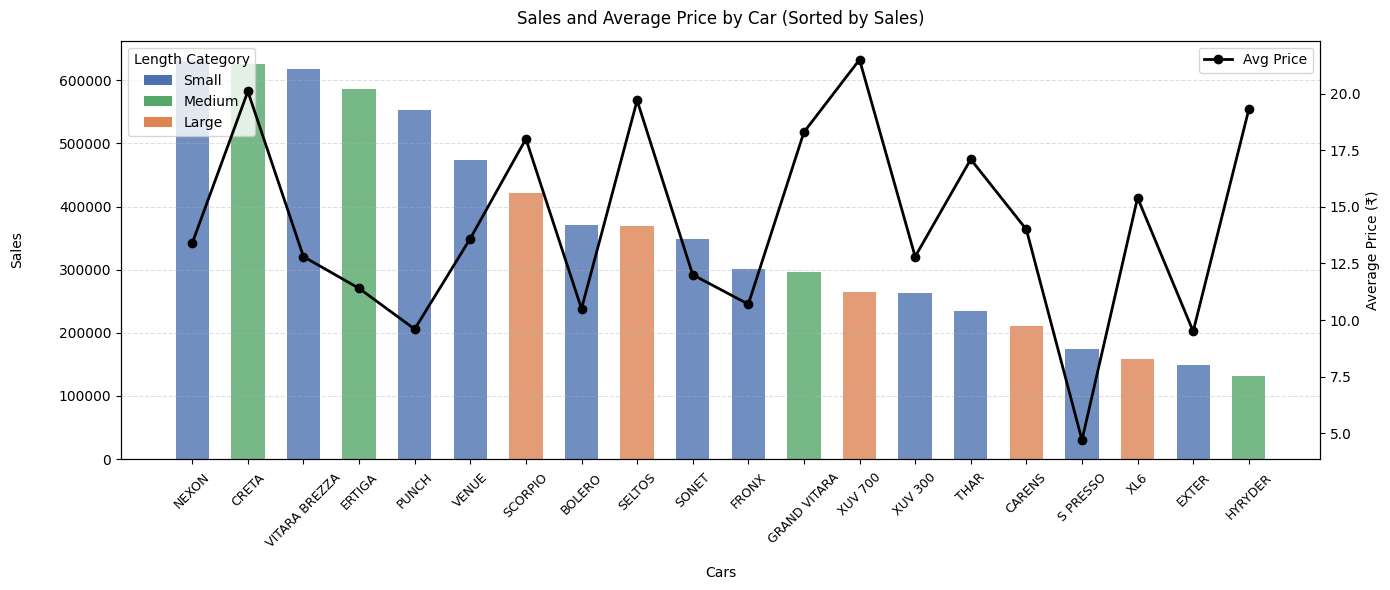

In [190]:
# 🔹 Keep model names from index as a column
spec_sorted = specifications_final.copy()
spec_sorted['model_name'] = spec_sorted.index  # save index into a column

# 🔹 Sort by sales descending
spec_sorted = spec_sorted.sort_values(by='sales', ascending=False).reset_index(drop=True)

# Data
x = np.arange(len(spec_sorted))
sales = spec_sorted['sales']
price = spec_sorted['price_avg']
length_cat = spec_sorted['Length Category']
models = spec_sorted['model_name']  # now we have the car names

# Color mapping for Length Category
color_map = {'Small': '#4C72B0', 'Medium': '#55A868', 'Large': '#DD8452'}
colors = length_cat.map(color_map)

fig, ax1 = plt.subplots(figsize=(14,6))

# 🔹 Bars for Sales
bars = ax1.bar(
    x,
    sales,
    color=colors,
    alpha=0.8,
    width=0.6
)

ax1.set_xlabel('Cars', labelpad = 70)
ax1.set_ylabel('Sales', labelpad = 25)
ax1.set_xticks(x)
ax1.set_xticklabels([])  # keep X-axis clean
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# 🔹 Add car names below bars
for i, bar in enumerate(bars):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        -max(sales)*0.03,  # slightly below bar base
        models[i],
        ha='center',
        va='top',
        rotation=45,
        fontsize=9
    )

# 🔹 Line for Average Price
ax2 = ax1.twinx()
ax2.plot(
    x,
    price,
    color='black',
    marker='o',
    linewidth=2,
    markersize=6,
    label='Avg Price'
)
ax2.set_ylabel('Average Price (₹)')

# 🔹 Legend for Length Category
legend_elements = [
    Patch(facecolor='#4C72B0', label='Small'),
    Patch(facecolor='#55A868', label='Medium'),
    Patch(facecolor='#DD8452', label='Large')
]
ax1.legend(handles=legend_elements, title='Length Category', loc='upper left')

# Optional: legend for line
ax2.legend(loc='upper right')

# Title
plt.title('Sales and Average Price by Car (Sorted by Sales)', pad=12)
plt.tight_layout()
plt.show()

Comparing Sales, Average Price and Length Category

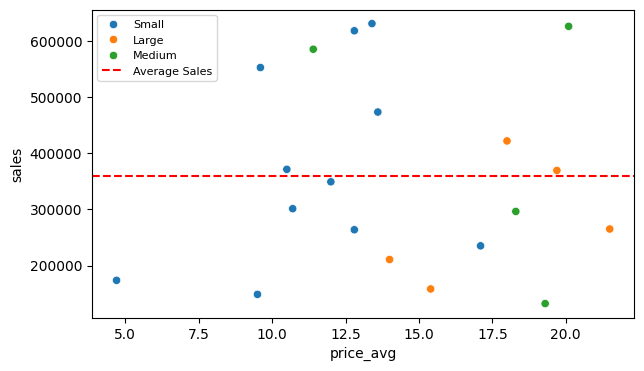

In [82]:
avg_sales = specifications_final['sales'].mean()
plt.figure(figsize=(7, 4))  # (width, height)
sns.scatterplot(x='price_avg', y='sales', hue='Length Category', data=specifications_final)
plt.axhline(y=avg_sales, color='red', linestyle='--', label='Average Sales')
# setting legend position
plt.legend(loc='upper left', fontsize = 8)  
plt.show()

Comparing Price (Starting, Average and Maximum) and Sales

In [83]:
# plt.figure(figsize=(6, 4.5))  # (width, height)
# sns.regplot(x='price_start', y='sales', data=specifications_final, scatter=False, color='green', label = 'Starting Price', ci = None)
# sns.regplot(x='price_avg', y='sales', data=specifications_final, scatter=False, color='blue', label = 'Average Price', ci = None)
# sns.regplot(x='price_max', y='sales', data=specifications_final, scatter=False, color='orange', label = 'Maximum Price', ci = None)
# # xticks in the interval of 2
# plt.xticks(np.arange(0, 32, 4))
# # setting x - limit
# plt.grid()
# plt.xlim(0, 32.0)
# plt.xlabel('Price Starting / Average / Maximum')
# plt.ylabel('Sales')
# plt.tight_layout()
# plt.legend()
# plt.show()

In [84]:
# scatter plot for starting price, average price and maximum price
# plt.figure(figsize=(7,3))
# sns.scatterplot(x='price_start', y='sales', data=specifications_final, color='blue', label='Starting Price')
# sns.scatterplot(x='price_avg', y='sales', data=specifications_final, color='green', label='Average Price')
# sns.scatterplot(x='price_max', y='sales', data=specifications_final, color='orange', label='Max Price')
# plt.grid(alpha = 0.3)
# plt.xticks(np.arange(0, 30, 2))
# plt.xlabel('Price')
# plt.ylabel('Sales')
# plt.title('Price vs Sales Comparison')
# plt.legend()
# plt.show()

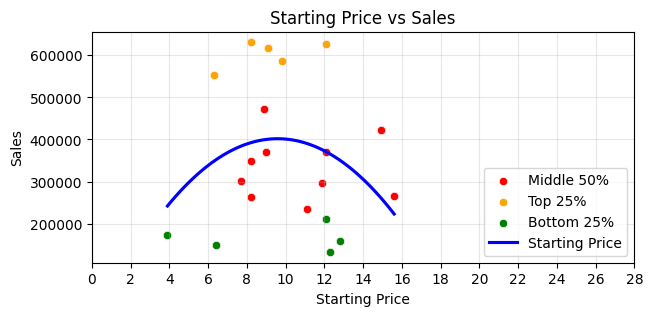

In [195]:
top_25_percent_sales = specifications_final.nlargest(5, 'sales')
bottom_25_percent_sales = specifications_final.nsmallest(5, 'sales')
plt.figure(figsize=(7,3))
sns.scatterplot(x='price_start', y='sales', data=specifications, color='red', label='Middle 50%')
sns.scatterplot(x='price_start', y='sales', data=top_25_percent_sales, color='orange', label='Top 25%')
sns.scatterplot(x='price_start', y='sales', data=bottom_25_percent_sales, color='green', label='Bottom 25%')
sns.regplot(x='price_start', y='sales', data=specifications_final, scatter=False, color='blue', label = 'Starting Price', ci = None, order = 2)

plt.grid(alpha = 0.3)
plt.xticks(np.arange(0, 30, 2))
plt.xlabel('Starting Price')
plt.ylabel('Sales')
plt.title('Starting Price vs Sales')
plt.legend(loc = 'lower right')
plt.show()

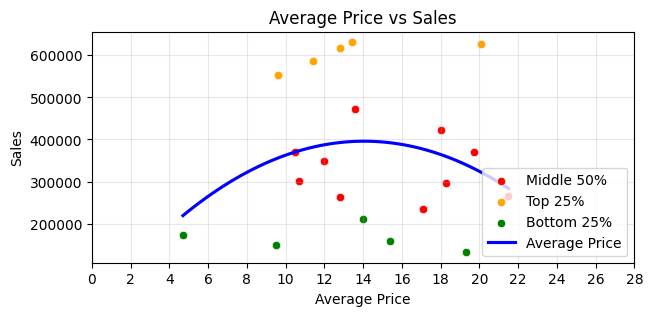

In [197]:
top_25_percent_sales = specifications_final.nlargest(5, 'sales')
bottom_25_percent_sales = specifications_final.nsmallest(5, 'sales')
plt.figure(figsize=(7,3))
sns.scatterplot(x='price_avg', y='sales', data=specifications, color='red', label='Middle 50%')
sns.scatterplot(x='price_avg', y='sales', data=top_25_percent_sales, color='orange', label='Top 25%')
sns.scatterplot(x='price_avg', y='sales', data=bottom_25_percent_sales, color='green', label='Bottom 25%')
sns.regplot(x='price_avg', y='sales', data=specifications_final, scatter=False, color='blue', label = 'Average Price', ci = None, order = 2)
plt.grid(alpha = 0.3)
plt.xticks(np.arange(0, 30, 2))
plt.xlabel('Average Price')
plt.ylabel('Sales')
plt.title('Average Price vs Sales')
plt.legend(loc = 'lower right')
plt.show()

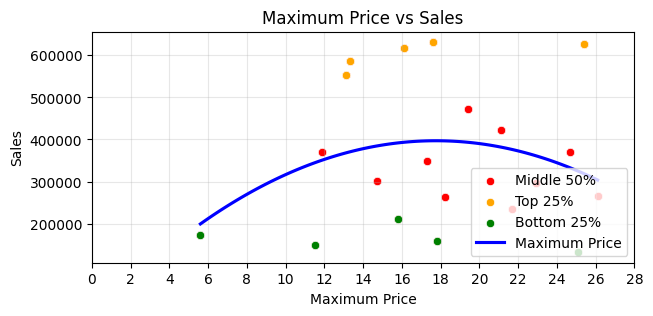

In [199]:
top_25_percent_sales = specifications_final.nlargest(5, 'sales')
bottom_25_percent_sales = specifications_final.nsmallest(5, 'sales')
plt.figure(figsize=(7,3))
sns.scatterplot(x='price_max', y='sales', data=specifications, color='red', label='Middle 50%')
sns.scatterplot(x='price_max', y='sales', data=top_25_percent_sales, color='orange', label='Top 25%')
sns.scatterplot(x='price_max', y='sales', data=bottom_25_percent_sales, color='green', label='Bottom 25%')
sns.regplot(x='price_max', y='sales', data=specifications_final, scatter=False, color='blue', label = 'Maximum Price', ci = None, order = 2)
plt.grid(alpha = 0.3)
plt.xticks(np.arange(0, 30, 2))
plt.xlabel('Maximum Price')
plt.ylabel('Sales')
plt.title('Maximum Price vs Sales')
plt.legend(loc = 'lower right')
plt.show()

Distribution of Price (Start, Average and Maximum)

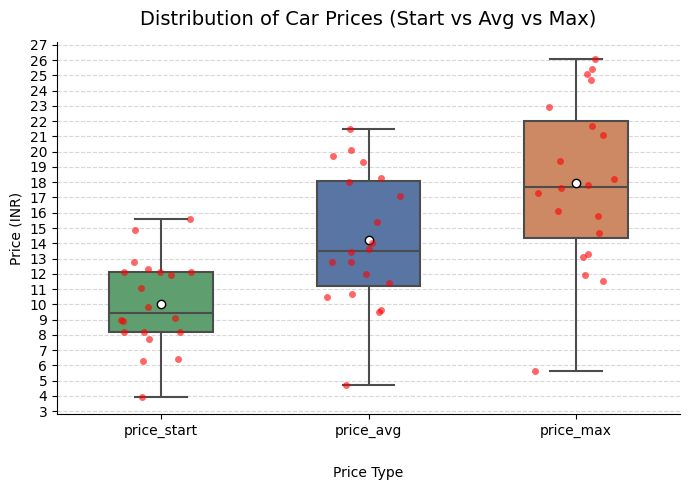

In [192]:
df_melted = specifications_final.melt(
    value_vars=['price_start', 'price_avg', 'price_max'],
    var_name='Price Type',
    value_name='Price'
)

plt.figure(figsize=(7, 5))

# Boxplot
sns.boxplot(
    x='Price Type',
    y='Price',
    data=df_melted,
    palette=['#55A868', '#4C72B0', '#DD8452'],  # green, blue, orange
    width=0.5,
    linewidth=1.5,
    showmeans=True,
    hue = 'Price Type',
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# Stripplot (optional but recommended)
sns.stripplot(
    x='Price Type',
    y='Price',
    data=df_melted,
    color='red',
    size=5,
    jitter=0.2,
    alpha=0.6
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Axis formatting
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(1))

# Labels & Title
plt.title('Distribution of Car Prices (Start vs Avg vs Max)', fontsize=14, pad=12)
plt.xlabel('Price Type', labelpad = 20)
plt.ylabel('Price (INR)')

# Clean look
sns.despine()

plt.tight_layout()
plt.show()

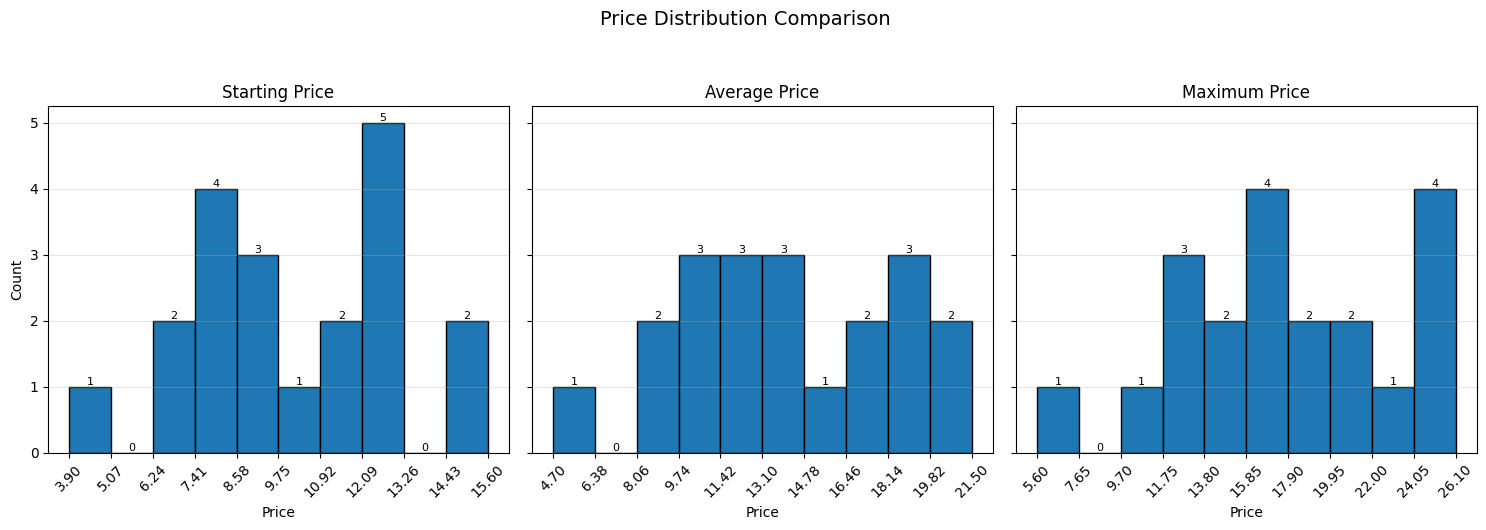

In [151]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

columns = ['price_start', 'price_avg', 'price_max']
titles = ['Starting Price', 'Average Price', 'Maximum Price']

for ax, col, title in zip(axes, columns, titles):
    counts, bins, patches = ax.hist(
        specifications_final[col],
        bins=10,
        edgecolor='black'
    )
    
    # Add values on bars
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        ax.text(x, y, int(count), ha='center', va='bottom', fontsize=8)
    
    # Axis formatting
    ax.set_xticks(bins)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(title)
    ax.set_xlabel('Price')
    ax.grid(axis='y', alpha=0.3)

# Shared Y label
axes[0].set_ylabel('Count')

plt.suptitle('Price Distribution Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [152]:
# # histogram for starting price
# plt.figure(figsize=(6,5))
# counts, bins, patches = plt.hist(
#     specifications_final['price_start'], 
#     bins=10,
#     edgecolor='black'
# )
# # Add values on top
# for count, patch in zip(counts, patches):
#     x = patch.get_x() + patch.get_width() / 2
#     y = patch.get_height()
#     plt.text(x, y, int(count), ha='center', va='bottom')
# # ✅ Align ticks with bin edges
# plt.xticks(bins, rotation=45)
# plt.xlabel('Starting Price')
# plt.ylabel('Count')
# plt.title('Price Distribution')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

In [154]:
# # histogram for average price
# plt.figure(figsize=(6,5))
# counts, bins, patches = plt.hist(
#     specifications_final['price_avg'], 
#     bins=10,
#     edgecolor='black'
# )
# # Add values on top
# for count, patch in zip(counts, patches):
#     x = patch.get_x() + patch.get_width() / 2
#     y = patch.get_height()
#     plt.text(x, y, int(count), ha='center', va='bottom')
# # ✅ Align ticks with bin edges
# plt.xticks(bins, rotation=45)
# plt.xlabel('Average Price')
# plt.ylabel('Count')
# plt.title('Price Distribution')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

In [153]:
# # histogram for maximum price
# plt.figure(figsize=(6,5))
# counts, bins, patches = plt.hist(
#     specifications_final['price_max'], 
#     bins=10,
#     edgecolor='black'
# )
# # Add values on top
# for count, patch in zip(counts, patches):
#     x = patch.get_x() + patch.get_width() / 2
#     y = patch.get_height()
#     plt.text(x, y, int(count), ha='center', va='bottom')
# # ✅ Align ticks with bin edges
# plt.xticks(bins, rotation=45)
# plt.xlabel('Maximum Price')
# plt.ylabel('Count')
# plt.title('Price Distribution')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()

Analyzing Displacement (Engine Volume)

In [91]:
specifications_final['Displacement'].value_counts()

Displacement
1500    12
1200     4
1000     2
2200     1
2000     1
Name: count, dtype: int64

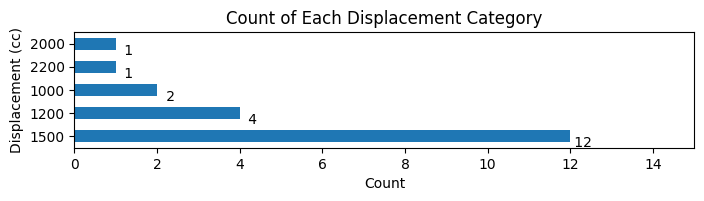

In [97]:
# comparing sales for each 'Length Category'
counts = specifications_final['Displacement'].value_counts()
plt.figure(figsize=(8, 1.5))  # (width, height)
ax = counts.plot(kind='barh')
# Add values on top of bars
for i, v in enumerate(counts):
    ax.text(v, i, '      ' + str(v), ha='center', va='top') 
plt.xlim([0, 15])
plt.xlabel('Count')
plt.ylabel('Displacement (cc)')
plt.title('Count of Each Displacement Category')
plt.show()

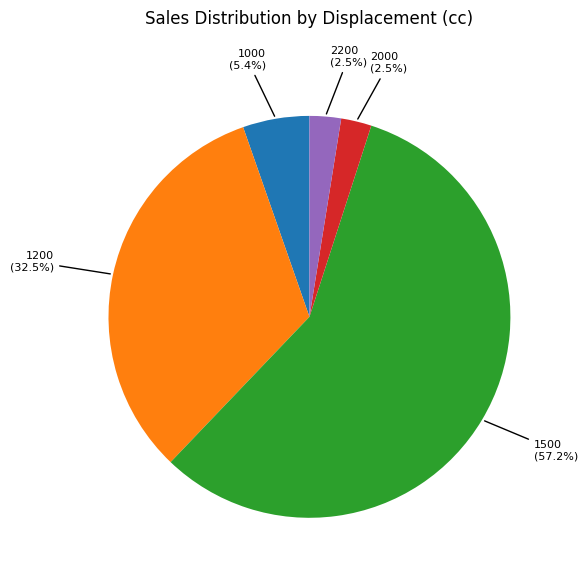

In [93]:
sales_by_displacement = specifications.groupby('Displacement')['sales'].sum()
plt.figure(figsize=(6, 6))   # 🔥 increase size
sizes = sales_by_displacement.values
labels = sales_by_displacement.index
total = sizes.sum()
wedges, _ = plt.pie(
    sizes,
    startangle=90
)
label_dist = 1.3   # 🔥 reduce from 1.6 → balanced
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    percentage = sizes[i] / total * 100
    label = f"{labels[i]}\n({percentage:.1f}%)"

    # smart alignment
    ha = 'left' if x > 0 else 'right'

    plt.annotate(
        label,
        xy=(x, y),
        xytext=(label_dist * x, label_dist * y),
        arrowprops=dict(arrowstyle='-'),
        ha=ha,                     # 🔥 dynamic alignment
        va='center',
        fontsize=8
    )

plt.title('Sales Distribution by Displacement (cc)', pad=25)
plt.axis('equal')
plt.tight_layout()
plt.show()

Analyzing Number of Cylinders

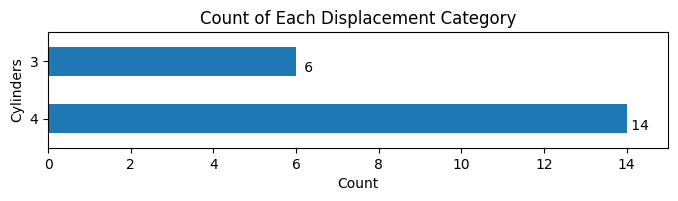

In [102]:
# comparing sales for each 'Length Category'
counts = specifications_final['cylinders'].value_counts()
plt.figure(figsize=(8, 1.5))  # (width, height)
ax = counts.plot(kind='barh')
# Add values on top of bars
for i, v in enumerate(counts):
    ax.text(v, i, '      ' + str(v), ha='center', va='top') 
plt.xlim([0, 15])
plt.xlabel('Count')
plt.ylabel('Cylinders')
plt.title('Count of Each Displacement Category')
plt.show()

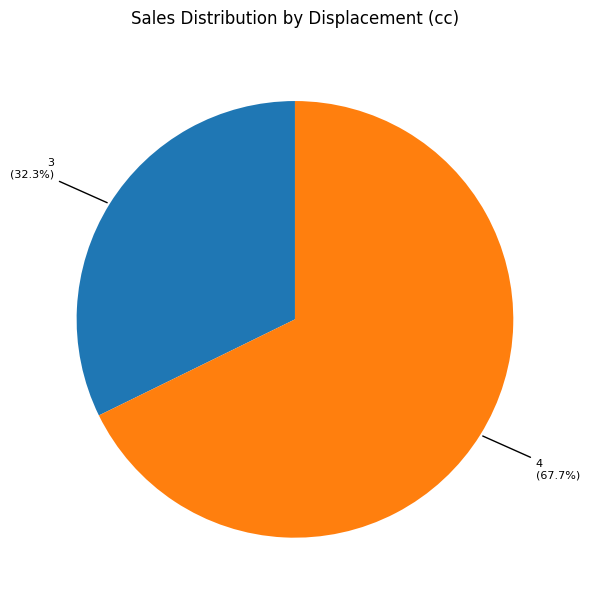

In [104]:
sales_by_cylinders = specifications.groupby('cylinders')['sales'].sum()
plt.figure(figsize=(6, 6))   # 🔥 increase size
sizes = sales_by_cylinders.values
labels = sales_by_cylinders.index
total = sizes.sum()
wedges, _ = plt.pie(
    sizes,
    startangle=90
)
label_dist = 1.3   # 🔥 reduce from 1.6 → balanced
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    percentage = sizes[i] / total * 100
    label = f"{labels[i]}\n({percentage:.1f}%)"

    # smart alignment
    ha = 'left' if x > 0 else 'right'

    plt.annotate(
        label,
        xy=(x, y),
        xytext=(label_dist * x, label_dist * y),
        arrowprops=dict(arrowstyle='-'),
        ha=ha,                     # 🔥 dynamic alignment
        va='center',
        fontsize=8
    )

plt.title('Sales Distribution by Displacement (cc)', pad=25)
plt.axis('equal')
plt.tight_layout()
plt.show()

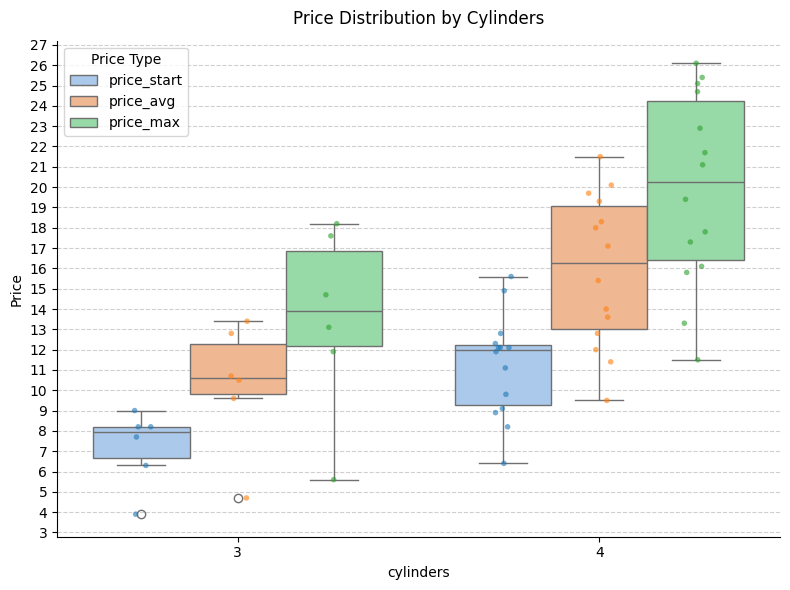

In [144]:
df_melted = specifications_final.melt(
    id_vars='cylinders',
    value_vars=['price_start', 'price_avg', 'price_max'],
    var_name='Price Type',
    value_name='Price'
)
plt.figure(figsize=(8, 6))
# Boxplot
sns.boxplot(
    x='cylinders',
    y='Price',
    hue='Price Type',
    data=df_melted,
    palette= 'pastel'  # blue, green, orange
)
# Stripplot
sns.stripplot(
    x='cylinders',
    y='Price',
    hue='Price Type',
    data=df_melted,
    dodge=True,
    # palatte ='black',
    size=4,
    alpha=0.6, 
)
# Fix duplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title='Price Type')
# Axis scale
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(1))
# Styling
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.title('Price Distribution by Cylinders', pad=12)

plt.tight_layout()
plt.show()